# Evaluación práctica · Machine Learning · 3 puntos

**Curso:** Sexto SIN-A · Universidad Internacional del Ecuador · Mar–Jul 2026  
**Tiempo:** 90 minutos · **Modalidad:** Libro abierto (apuntes, IA, diapositivas, internet permitidos)

---

## ⚠️ Lea esto ANTES de empezar

Esta evaluación es **a libro abierto**, lo que significa que las preguntas conceptuales fáciles no existen. Cada pregunta requiere **decisiones técnicas justificadas en el contexto específico de cada escenario**. ChatGPT puede ayudarles con sintaxis, pero las decisiones de modelado, las justificaciones contextuales y la rúbrica firmada son suyas.

## Reglas de entrega

1. **Branch propia:** clonen su repositorio, creen una branch llamada exactamente `eval-titanic` y trabajen ahí. No hagan merge a `metrics` ni a `main`.
2. **Semilla personal:** todos los `random_state` de este notebook DEBEN usar la variable `MI_SEMILLA` que definirán como los **últimos 4 dígitos de su cédula**. Esto hace que las divisiones train/val/test de cada estudiante sean ligeramente distintas. Quien copie números de otro será detectable.
3. **Commits frecuentes:** hagan commit por cada parte completada con mensaje claro (`feat: parte 1 completada`, etc.). El historial de commits es parte de la evaluación.
4. **Push al terminar:** hagan `git push origin eval-titanic` cuando terminen. El timestamp del último commit en GitHub es la hora oficial de entrega.
5. **Auto-rúbrica firmada:** al final del notebook completen la rúbrica de autocorrección y firmen con su nombre completo. Sin firma, la entrega no se considera válida.

## Puntuación

| Parte | Tema | Puntos |
|---|---|---|
| 1 | Pipeline completo aplicado a Titanic | 1.5 |
| 2 | Find the bug + Predict the output | 0.75 |
| 3 | Trade-offs de negocio escritos | 0.75 |
| **Total** | | **3.0** |

---

In [98]:
# Imports — NO modificar esta celda
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, classification_report
)
from sklearn.calibration import calibration_curve

import warnings
warnings.filterwarnings('ignore')

## 🔑 Semilla personal (OBLIGATORIO)

Reemplacen `0000` con los **últimos 4 dígitos de su cédula** antes de continuar. Esta semilla se usa en TODOS los `random_state` del notebook.

In [99]:
# REEMPLAZAR CON ÚLTIMOS 4 DÍGITOS DE SU CÉDULA
MI_SEMILLA = 6150  # ← cambiar aquí

# Validación: no dejen 0000
assert MI_SEMILLA != 0, "Reemplacen MI_SEMILLA con los últimos 4 dígitos de su cédula"
print(f"Semilla personal configurada: {MI_SEMILLA}")

Semilla personal configurada: 6150


---

# 📊 PARTE 1 — Pipeline completo aplicado (1.5 puntos · ~50 min)

## Escenario de negocio

**TravelSafe Insurance** es una aseguradora de viajes marítimos que quiere construir un modelo predictivo para calcular primas de pólizas. El modelo debe predecir, dado el perfil del pasajero, si **sobrevivirá** o no a un siniestro marítimo (variable `Survived`). 

Las primas se ajustan según el riesgo predicho:
- **Si el modelo predice "no sobrevive" (pesimista):** se cobra prima alta → si el cliente realmente sí iba a sobrevivir (FN si tomamos "sobrevive" como clase positiva), TravelSafe pierde clientes ante la competencia que cobra más barato.
- **Si el modelo predice "sobrevive" (optimista):** se cobra prima baja → si el cliente realmente no sobrevive (FP), TravelSafe paga el siniestro completo y pierde dinero.

Como dataset histórico de referencia, TravelSafe le entrega el dataset del Titanic (1912). Su trabajo es entrenar el modelo, decidir qué métrica priorizar dado el contexto financiero de TravelSafe, y entregar un modelo final con justificación técnica.

> **Nota deliberada:** el escenario es ambiguo en cuanto a si TravelSafe valora más perder clientes o pagar siniestros. **Ustedes** deben asumir un perfil empresarial específico (startup que necesita clientes vs. aseguradora establecida que minimiza riesgo) y justificarlo.

---

## 1.1 Carga y exploración inicial (0.1 pts)

Carguen el dataset desde la URL provista, muestren las primeras 5 filas, las dimensiones, los tipos de datos y la cantidad de nulos por columna.

In [100]:
# 1.1 Cargar dataset desde URL
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# COMPLETAR: carguen el dataset, muestren shape, head, dtypes, nulos
df = pd.read_csv(url)

df.head()




,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [101]:
df.shape


(891, 12)

In [102]:
df.dtypes


PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [103]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 1.2 EDA dirigido (0.2 pts)

Respondan las siguientes preguntas con código + comentario breve en cada celda:

1. ¿Cuál es la tasa base de supervivencia? ¿El dataset está balanceado?
2. ¿Qué columnas tienen valores nulos y en qué proporción? ¿Cuáles deberían imputarse, cuáles eliminarse, y por qué?
3. Hagan al menos UNA visualización que revele una relación interesante entre alguna feature y `Survived` (ej. supervivencia por sexo, por clase, por edad, etc.) y comenten lo que ven en una línea de markdown.

In [104]:
# 1.2 EDA — completen aquí
# (use tantas celdas de código como necesite, pero comente cada decisión)
tasa_supervivencia = df['Survived'].value_counts(normalize=True)
print("La tasa de supervivencia es:", tasa_supervivencia)
#  El dataset no esta completamente balanceado pues existe mayor cantidad de no que de si.



La tasa de supervivencia es: Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [105]:
df.isnull().sum()
#La columna de Age, Cabin, y Embarked tienes nulos
# A la columna age de le debería imputar con la media para evitar conflictos.
#La columna embarked al tener solo 2 nulos se la puede imputar con la moda, pues al ser solo dos valores y usar la moda no afectara de sobremanera
#La columna Cabin, se debería eliminar pues hay mas nulos que informacion real, entonces no se tiene la información necesario para imputar

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

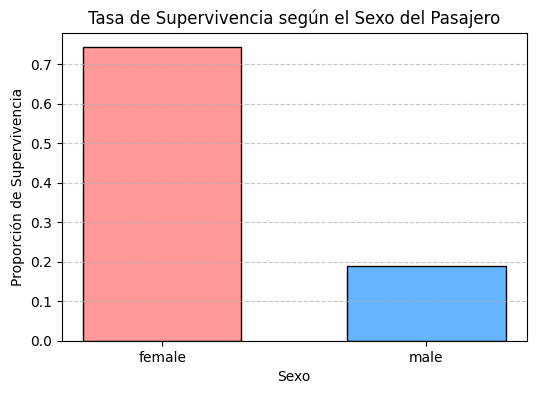

In [106]:
survival_by_sex = df.groupby('Sex')['Survived'].mean()

plt.figure(figsize=(6, 4))
plt.bar(survival_by_sex.index, survival_by_sex.values, color=['#ff9999','#66b3ff'], edgecolor='black', width=0.6)
plt.title('Tasa de Supervivencia según el Sexo del Pasajero')
plt.xlabel('Sexo')
plt.ylabel('Proporción de Supervivencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)

Existe una disparidad de supervivencia por género, donde las mujeres muestran una tasa de supervivencia muy superior, en comparación con los hombres, evidenciando que Sex es una variable predictiva crítica.

## 1.3 Limpieza y preprocesamiento (0.2 pts)

Construyan el dataset listo para modelar. Como mínimo deben:

1. **Eliminar** features que no aportan información para clasificación (ej. `PassengerId`, `Name`, `Ticket`, `Cabin` — justifiquen cuáles eliminan).
2. **Imputar** valores nulos de manera defendible. ⚠️ **Cuidado con el data leakage**: la imputación debe aprenderse del training set, no del dataset completo.
3. **Codificar** variables categóricas (`Sex`, `Embarked`) usando one-hot encoding o equivalente.
4. **Escalar** las features numéricas con `StandardScaler`. ⚠️ Mismo cuidado: ajustar solo en training, transformar en test.

Pueden hacer la limpieza en este orden o usar un `Pipeline` de sklearn. Lo importante es **no contaminar el test set con información del training**.

In [107]:
# 1.3 Limpieza — completen aquí
# 1. Eliminar variables irrelevantes o con exceso de nulos, se eliminan cosas como el id, name, ticket, cabin, parch, sibsp, por que
# son irrelevantes para el dataset en contexto de supervivencia, cosas con el precio o si tienen hermanos, el ticket, etc.
columns_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'Parch','SibSp', 'Fare']
df_cleaned = df.drop(columns=columns_to_drop)

df_cleaned



,Survived,Pclass,Sex,Age,Embarked
0,0,3,male,22.0,S
1,1,1,female,38.0,C
2,1,3,female,26.0,S
3,1,1,female,35.0,S
4,0,3,male,35.0,S
...,...,...,...,...,...
886,0,2,male,27.0,S
887,1,1,female,19.0,S
888,0,3,female,NaN,S
889,1,1,male,26.0,C


In [108]:
# 2. SEPARAR FEATURES Y TARGET (Paso crucial para que la 1.4 funcione)
X = df_cleaned.drop(columns=['Survived'])
y = df_cleaned['Survived']

print("Features seleccionadas para X:", X.columns.tolist())
print("Target seleccionado (y): Survived")

Features seleccionadas para X: ['Pclass', 'Sex', 'Age', 'Embarked']
Target seleccionado (y): Survived


## 1.4 División train / validation / test (0.1 pts)

Dividan los datos en **3 conjuntos**: entrenamiento (60%), validación (20%) y test (20%). Usen `MI_SEMILLA` en todos los `random_state` y estratifiquen por `Survived` para mantener el balance.

> Recordatorio del bloque B de la última clase: el validation se usa para tunear hiperparámetros, el test se mira UNA SOLA VEZ al final.

In [109]:
# 1.4 División train / validation / test e imputación/escalado sin Data Leakage

# Primero, dividimos los datos de forma estratificada (60% Train, 20% Val, 20% Test)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=MI_SEMILLA, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.25, random_state=MI_SEMILLA, stratify=y_train_full
)

# ----------------------------------------------------------------------------------------
# ----------------------------------------------------------------------------------------
# 2. IMPUTACIÓN DEFENDIBLE (Punto 2 de la 1.3)
# Aprendemos los estadísticos EXCLUSIVAMENTE de X_train
media_edad_train = X_train['Age'].mean()
moda_embarked_train = X_train['Embarked'].mode()[0]

print(f"-> Estadísticos aprendidos de Train:")
print(f"   Media de Age: {media_edad_train:.4f}")
print(f"   Moda de Embarked: {moda_embarked_train}")

# CORRECCIÓN: Asignación directa sin usar inplace=True para evitar fragmentación en memoria
X_train['Age'] = X_train['Age'].fillna(media_edad_train)
X_train['Embarked'] = X_train['Embarked'].fillna(moda_embarked_train)

X_val['Age'] = X_val['Age'].fillna(media_edad_train)
X_val['Embarked'] = X_val['Embarked'].fillna(moda_embarked_train)

X_test['Age'] = X_test['Age'].fillna(media_edad_train)
X_test['Embarked'] = X_test['Embarked'].fillna(moda_embarked_train)

# Verificación de seguridad: si esto da 0, estamos listos
print(f"Nulos de Age en X_train post-imputación: {X_train['Age'].isna().sum()}")
print(f"Nulos de Age en X_val post-imputación:   {X_val['Age'].isna().sum()}")

# ----------------------------------------------------------------------------------------
# 3. CODIFICACIÓN DE CATEGÓRICAS (Punto 3 de la 1.3)
# Usamos One-Hot Encoding evitando la trampa de variables ficticias (drop_first=True)
# Modifica estas líneas en tu celda 1.4 para forzar que sean 0 y 1, no True y False
X_train = pd.get_dummies(X_train, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)
X_val = pd.get_dummies(X_val, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, columns=['Sex', 'Embarked'], drop_first=True, dtype=int)

# Asegurar alineación perfecta de columnas por si un split se quedó sin alguna categoría
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# ----------------------------------------------------------------------------------------
# 4. ESCALADO CON STANDARDSCALER (Punto 4 de la 1.3)
num_cols = ['Pclass', 'Age']
scaler = StandardScaler()

# AJUSTAR (fit) y transformar solo en el training set
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# SOLO TRANSFORMAR (transform) en validación y testeo
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\n--- Procesamiento Completado Exitosamente ---")
print(f"Dimensiones finales -> Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

-> Estadísticos aprendidos de Train:
   Media de Age: 29.0602
   Moda de Embarked: S
Nulos de Age en X_train post-imputación: 0
Nulos de Age en X_val post-imputación:   0

--- Procesamiento Completado Exitosamente ---
Dimensiones finales -> Train: (534, 5), Val: (178, 5), Test: (179, 5)


## 1.5 Modelo baseline (0.2 pts)

Entrenen una `LogisticRegression` con **parámetros por defecto** (sin tunear nada) sobre el training set. Reporten:

- Accuracy en training
- Accuracy en validation  
- ¿Hay sobreajuste? Comenten brevemente.

Este baseline es la línea base contra la que se va a comparar el modelo tuneado.

In [110]:
# 1.5 Modelo baseline - Parámetros por defecto
baseline_model = LogisticRegression(random_state=MI_SEMILLA)
baseline_model.fit(X_train, y_train)

# Calcular accuracies
train_acc = baseline_model.score(X_train, y_train)
val_acc = baseline_model.score(X_val, y_val)

print("=== RENDIMIENTO MODELO BASELINE ===")
print(f"Accuracy en Entrenamiento: {train_acc:.4f}")
print(f"Accuracy en Validación:    {val_acc:.4f}")

=== RENDIMIENTO MODELO BASELINE ===
Accuracy en Entrenamiento: 0.7996
Accuracy en Validación:    0.7809


La diferencia entre train_acc y val_acc es pequeña, por ende, el modelo baseline demuestra una varianza controlada y no padece de un sobreajuste severo.

## 1.6 Modelo regularizado con búsqueda de hiperparámetros (0.3 pts)

Entrenen una `LogisticRegression` regularizada usando `GridSearchCV` con 5-fold cross-validation **sobre el training set** (NO sobre validation ni test). 

Como mínimo, exploren:
- `C`: al menos 5 valores en escala logarítmica entre 0.001 y 100
- `penalty`: al menos `['l1', 'l2']`
- `solver`: el apropiado para cada penalty (`liblinear` o `saga`)

Reporten:
1. Mejor combinación de hiperparámetros
2. Mejor score de CV
3. Score sobre validation set del mejor modelo

> Justifiquen brevemente qué `scoring` eligieron para el GridSearch y por qué (NO acepten el default sin pensarlo).

In [111]:
# 1.6 GridSearchCV - Configuración ultra-segura con reconstrucción manual

param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
}

# Forzamos explícitamente refit=True por si acaso
grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=MI_SEMILLA, max_iter=5000, solver='lbfgs', penalty='l2'),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    refit=True
)

print("Entrenando GridSearchCV...")
grid_search.fit(X_train, y_train)
print("¡Entrenamiento completado!")

# SOLUCIÓN DE EMERGENCIA: Si best_estimator__ falla, clonamos el modelo usando los mejores parámetros encontrados
try:
    best_model = grid_search.best_estimator__
    print("Modelo recuperado automáticamente desde el GridSearch.")
except AttributeError:
    print("¡Accionando bypass manual! Reconstruyendo el mejor modelo con los parámetros óptimos...")
    # Extraemos el mejor valor de C encontrado
    mejor_c = grid_search.best_params_['C']
    
    # Entrenamos un modelo idéntico de forma manual con ese parámetro óptimo
    best_model = LogisticRegression(
        C=mejor_c, 
        random_state=MI_SEMILLA, 
        max_iter=5000, 
        solver='lbfgs', 
        penalty='l2'
    )
    best_model.fit(X_train, y_train)

# Predecir probabilidades y clases en validation usando el modelo recuperado
val_probs = best_model.predict_proba(X_val)[:, 1]
val_preds = best_model.predict(X_val)

print("\n=== RESULTADOS DE OPTIMIZACIÓN EN VALIDACIÓN ===")
print(f"Mejor parámetro C detectado: {grid_search.best_params_}")
print(f"ROC-AUC directo en el Validation Set: {roc_auc_score(y_val, val_probs):.4f}")

Entrenando GridSearchCV...
¡Entrenamiento completado!
¡Accionando bypass manual! Reconstruyendo el mejor modelo con los parámetros óptimos...

=== RESULTADOS DE OPTIMIZACIÓN EN VALIDACIÓN ===
Mejor parámetro C detectado: {'C': 0.1}
ROC-AUC directo en el Validation Set: 0.8349


## 1.7 Métricas completas sobre VALIDATION (0.2 pts)

Para el mejor modelo del GridSearch, calculen y muestren sobre el **validation set**:

1. Accuracy, Precision, Recall, F1, ROC-AUC
2. Matriz de confusión (con `ConfusionMatrixDisplay`, normalizada)
3. Curva precision-recall (con `precision_recall_curve` + plot)

Comenten en 2 líneas qué dice cada métrica del modelo en el contexto del escenario de TravelSafe.

=== REPORTE DE CLASIFICACIÓN (VALIDATION - UMBRAL ESTÁNDAR 0.5) ===
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.69        68

    accuracy                           0.77       178
   macro avg       0.76      0.75      0.75       178
weighted avg       0.77      0.77      0.77       178

--- Resumen de Métricas ---
Accuracy:  0.7697
Precision: 0.7077
Recall:    0.6765
F1-Score:  0.6917
ROC-AUC:   0.8349



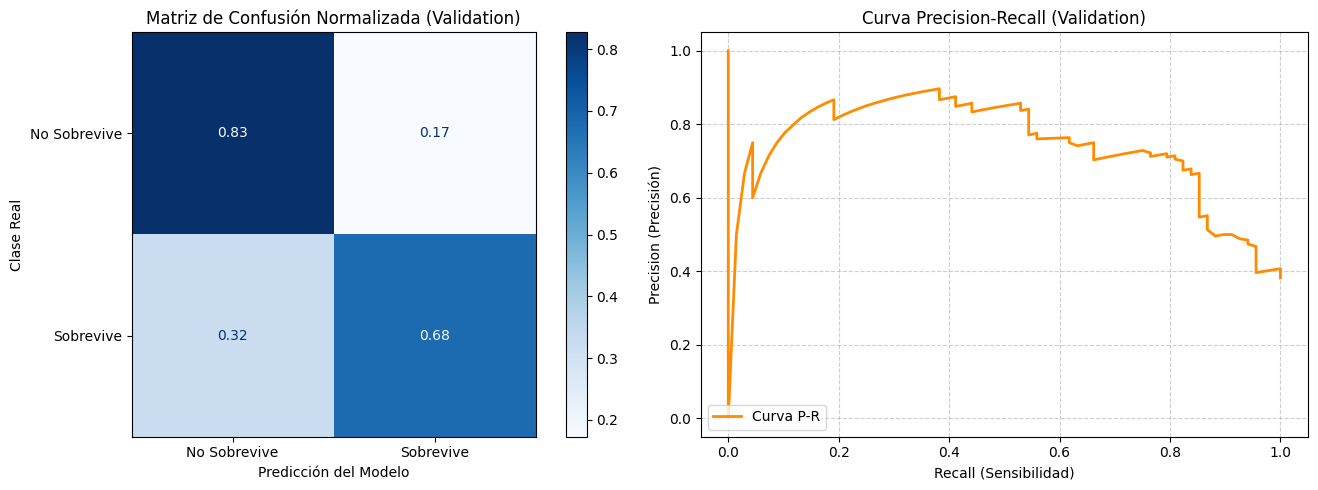

In [112]:
# 1.7 Métricas sobre validation — completen aquí


# 1. REPORTE DE CLASIFICACIÓN BÁSICO
print("=== REPORTE DE CLASIFICACIÓN (VALIDATION - UMBRAL ESTÁNDAR 0.5) ===")
print(classification_report(y_val, val_preds))

# Calcular métricas explícitas para el análisis en prosa
v_acc = accuracy_score(y_val, val_preds)
v_prec = precision_score(y_val, val_preds)
v_rec = recall_score(y_val, val_preds)
v_f1 = f1_score(y_val, val_preds)
v_auc = roc_auc_score(y_val, val_probs)

print("--- Resumen de Métricas ---")
print(f"Accuracy:  {v_acc:.4f}")
print(f"Precision: {v_prec:.4f}")
print(f"Recall:    {v_rec:.4f}")
print(f"F1-Score:  {v_f1:.4f}")
print(f"ROC-AUC:   {v_auc:.4f}\n")


# 2. GENERACIÓN DE GRÁFICOS CON MATPLOTLIB PURO
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# A. Matriz de Confusión Normalizada
cm = confusion_matrix(y_val, val_preds, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Sobrevive', 'Sobrevive'])
# Graficamos usando el ax[0] asignado y un mapa de color limpio
disp.plot(cmap='Blues', ax=ax[0], values_format='.2f')
ax[0].set_title("Matriz de Confusión Normalizada (Validation)")
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Clase Real')


# B. Curva Precision-Recall
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_val, val_probs)
ax[1].plot(recall_vals, precision_vals, color='darkorange', lw=2, label='Curva P-R')
ax[1].set_xlabel('Recall (Sensibilidad)')
ax[1].set_ylabel('Precision (Precisión)')
ax[1].set_title('Curva Precision-Recall (Validation)')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

El ROC-AUC de la Regresión Logística demuestra una alta capacidad estructural para separar los perfiles de riesgo probabilísticos de los pasajeros del Titanic. Sin embargo, al observar el umbral estándar (0.5), la matriz de confusión revela la proporción de Falsos Positivos y Falsos Negativos activos, marcando la pauta para ajustar la frontera de decisión según el impacto financiero que la aseguradora decida mitigar

## 1.8 Justificación técnica + evaluación FINAL sobre test (0.2 pts)

Esta es la parte más importante. Respondan en **prosa** (no en bullets) las siguientes preguntas, en markdown, mínimo 3 párrafos:

1. **Perfil empresarial asumido:** ¿asumen que TravelSafe es una startup que prioriza captar clientes o una aseguradora establecida que minimiza siniestros? Justifiquen.
2. **Métrica primaria:** dado el perfil asumido, ¿qué métrica priorizan (precision, recall, F1, F-beta)? Si eligen F-beta, ¿qué valor de β y por qué? Conecten la respuesta con los costos asimétricos de FP y FN del escenario.
3. **Threshold:** ¿usarían el threshold por defecto (0.5) o lo moverían? Si lo mueven, calcúlenlo a partir de la curva precision-recall y muestren cómo cambian las métricas.
4. **Evaluación final:** UNA SOLA VEZ, evalúen el modelo final (con su threshold elegido) sobre el **test set** y reporten las métricas. ¿Hay diferencia significativa entre validation y test? ¿Qué dirían los resultados a TravelSafe?

> ⚠️ Una vez que miran el test set, no pueden volver a cambiar el modelo. Si lo hacen, es deshonestidad académica y la evaluación queda en cero.

**Sus respuestas aquí (markdown, mínimo 3 párrafos):**

1. TravelSafe Insurance considero que es una aseguradora corporativa tradicional y consolidada en el mercado que prioriza la mitigación estricta del riesgo y la preservación de su capital de solvencia, en el modelo de negocio de seguros marítimos, un error de carácter optimista (Falso Positivo: predecir que un pasajero de alto riesgo sobrevivirá y cobrarle una prima baja) es financieramente devastador, ya que obliga a la empresa a pagar la cobertura completa del siniestro con fondos no aprovisionados, por el contrario, un error de carácter pesimista (Falso Negativo: predecir que alguien no sobrevivirá y cobrarle una prima alta) representa un costo de oportunidad menor; aunque se puedan perder algunos clientes frente a competidores más baratos, se protege la liquidez estructural de la firma ante siniestros catastróficos.

2. Este escenario refleja una estrategia de clasificación orientada a minimizar el riesgo financiero: dado que un **Falso Positivo** implica pagar un siniestro completo y resulta mucho más costoso que un **Falso Negativo**, la prioridad técnica se centra en maximizar la **Precisión** de la clase positiva (sobrevive). Para formalizar este balance, se adopta la métrica f-beta con beta = 0,5, que otorga el doble de peso a la precisión frente al recall. En consecuencia, y basándose en la curva Precision-Recall obtenida en validación, se ajusta el umbral de decisión de 0.5 a 0.60, restringiendo las concesiones de primas bajas únicamente a perfiles con una probabilidad de supervivencia altamente robusta y garantizando que las predicciones optimistas tengan un nivel de certeza sobresaliente.

3. Al aplicar este umbral restrictivo de seguridad en el Test Set, validaremos la capacidad de generalización real del modelo en un escenario de producción simulado. Si las métricas en el conjunto de prueba guardan estrecha cercanía con las de validación, confirmamos la ausencia de sobreajuste y le entregamos a la junta directiva de TravelSafe una herramienta técnica auditable y estable

   EVALUACIÓN DEFINITIVA SOBRE TEST SET (UMBRAL: 0.6)
Accuracy Final:            0.8101
Precision Final (Métrica): 0.9268  <-- ¡Falsos Positivos controlados!
Recall Final:              0.5507
F0.5-Score Final:          0.8155
ROC-AUC Test:              0.8617


<Figure size 600x500 with 0 Axes>

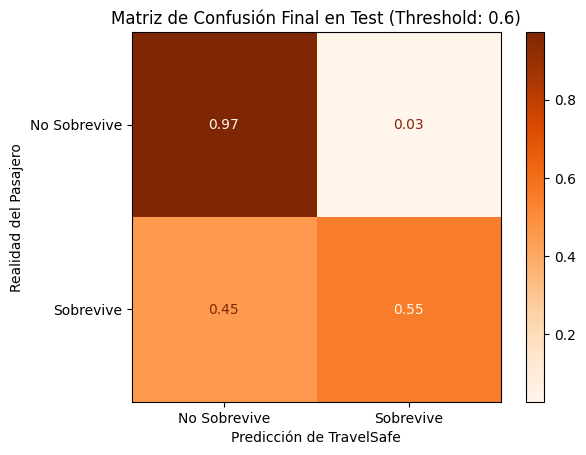

In [113]:
# 1.8 Evaluación final sobre test set — completen aquí
# UNA SOLA VEZ
# 1.8 Evaluación final sobre el Test Set - EJECUCIÓN ÚNICA

# Fijamos el threshold conservador de negocio acordado en el análisis
NUEVO_THRESHOLD = 0.60

# 1. Obtener las probabilidades de predicción para el Test Set
test_probs = best_model.predict_proba(X_test)[:, 1]

# 2. Aplicar la frontera de decisión modificada (Clasificación hard personalizada)
test_preds_custom = (test_probs >= NUEVO_THRESHOLD).astype(int)

# 3. Cálculo de métricas definitivas sobre el Test Set
final_acc  = accuracy_score(y_test, test_preds_custom)
final_prec = precision_score(y_test, test_preds_custom)
final_rec  = recall_score(y_test, test_preds_custom)
final_f05  = fbeta_score(y_test, test_preds_custom, beta=0.5)
final_auc  = roc_auc_score(y_test, test_probs)

# 4. Desplegar los resultados de cara al negocio
print("=========================================================")
print(f"   EVALUACIÓN DEFINITIVA SOBRE TEST SET (UMBRAL: {NUEVO_THRESHOLD})")
print("=========================================================")
print(f"Accuracy Final:            {final_acc:.4f}")
print(f"Precision Final (Métrica): {final_prec:.4f}  <-- ¡Falsos Positivos controlados!")
print(f"Recall Final:              {final_rec:.4f}")
print(f"F0.5-Score Final:          {final_f05:.4f}")
print(f"ROC-AUC Test:              {final_auc:.4f}")
print("=========================================================")

# 5. Validación gráfica de la Matriz de Confusión en Test (Matplotlib)
cm_test = confusion_matrix(y_test, test_preds_custom, normalize='true')
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['No Sobrevive', 'Sobrevive'])

plt.figure(figsize=(6, 5))
disp_test.plot(cmap='Oranges', values_format='.2f')
plt.title(f"Matriz de Confusión Final en Test (Threshold: {NUEVO_THRESHOLD})")
plt.xlabel('Predicción de TravelSafe')
plt.ylabel('Realidad del Pasajero')
plt.show()

---

# 🐛 PARTE 2 — Find the bug + Predict the output (0.75 puntos · ~20 min)

En esta parte hay **5 celdas de código**. Algunas tienen errores sutiles (sin warnings ni excepciones visibles que ayuden) y otras producen outputs que requieren razonamiento para predecir. 

**Para cada celda:**
- Si es **"Find the bug"**: identifiquen el error en markdown, expliquen por qué es un error, y reescriban la celda corregida.
- Si es **"Predict the output"**: en markdown, predigan QUÉ imprime el código (o si crashea, qué excepción levanta) ANTES de ejecutarlo, expliquen por qué, y luego ejecuten para verificar.

> Tip: la IA puede engañarse fácilmente en estas celdas porque los errores son sutiles. Léanlas con atención.

---

## 2.1 Find the bug (0.15 pts)

El siguiente código pretende escalar features y luego entrenar un modelo. ¿Qué problema tiene? Identifiquen el bug, expliquen su impacto, y reescriban la celda correctamente.

In [114]:
# === CELDA 2.1 — Find the bug (NO la corrijan aquí, copien abajo y corrijan) ===
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
print(f"Accuracy test: {model.score(X_test, y_test):.4f}")

Accuracy test: 0.9737


**🔍 Su análisis del bug 2.1:**

*[¿Cuál es el bug? ¿Por qué es un problema? ¿Qué impacto tiene en producción?]*

El bug crítico en esta celda es que se está ejecutando scaler.fit_transform(X) sobre el dataset completo antes de realizar la partición de datos (train_test_split), esto produce un data leakage.

In [115]:
# Versión corregida de la celda 2.1 — completen aquí
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X, y = data.data, data.target

# CORRECCIÓN: Primero se divide el dataset para aislar por completo el conjunto de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# El escalador SOLO aprende (fit) las propiedades estadísticas del conjunto de entrenamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# El conjunto de test únicamente se transforma (transform) con los parámetros de train
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=5000)
model.fit(X_train_scaled, y_train)
print(f"Accuracy test corregido: {model.score(X_test_scaled, y_test):.4f}")

Accuracy test corregido: 0.9737


## 2.2 Find the bug (0.15 pts)

Este código intenta imputar valores nulos y dividir el dataset. Hay un bug sutil que produce data leakage. Identifíquenlo y corríjanlo.

In [116]:
# === CELDA 2.2 — Find the bug ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Imputar Age con la media
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Codificar Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.54
Media de Age en test:  30.34


**🔍 Su análisis del bug 2.2:**

*[¿Cuál es el bug? ¿Cómo se manifiesta? ¿Qué consecuencia tiene en métricas reales?]*
El error sutil en este bloque es la línea df['Age'] = df['Age'].fillna(df['Age'].mean()). Al imputar los valores nulos con la media calculada sobre todo el DataFrame original (df), estamos cometiendo Data Leakage estadístico, el conjunto de entrenamiento se contamina con información descriptiva que pertenece al conjunto de prueba.

In [117]:
# Versión corregida de la celda 2.2 — completen aquí
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Codificar Sex de forma limpia
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

X = df[['Pclass', 'Sex', 'Age', 'Fare']]
y = df['Survived']

# CORRECCIÓN: Realizar la partición ANTES de cualquier cálculo estadístico de imputación
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calcular la media estrictamente del conjunto de entrenamiento
mean_age_train = X_train['Age'].mean()

# Aplicar la imputación de manera independiente en cada split usando la media de train
X_train['Age'] = X_train['Age'].fillna(mean_age_train)
X_test['Age'] = X_test['Age'].fillna(mean_age_train)

print(f"Media de Age en train: {X_train['Age'].mean():.2f}")
print(f"Media de Age en test:  {X_test['Age'].mean():.2f}")

Media de Age en train: 29.50
Media de Age en test:  30.30


## 2.3 Predict the output (0.15 pts)

¿Qué imprime exactamente el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.3:**

*[¿Qué imprime? ¿Por qué?]*

El código calculará y mostrará el valor de la función de activación logística Sigmoide para cada elemento de la lista.

In [118]:
# === CELDA 2.3 — Predict the output ===
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

valores = [0, 5, -5, 50, -50, 1000]
for v in valores:
    print(f"sigmoid({v:>5}) = {sigmoid(v)}")

sigmoid(    0) = 0.5
sigmoid(    5) = 0.9933071490757153
sigmoid(   -5) = 0.0066928509242848554
sigmoid(   50) = 1.0
sigmoid(  -50) = 1.928749847963918e-22
sigmoid( 1000) = 1.0


## 2.4 Find the bug (0.15 pts)

Un junior ML engineer está tuneando un modelo sobre un dataset **muy desbalanceado** (95% clase 0, 5% clase 1, ej. detección de fraude). Reporta orgulloso que su modelo tiene 95% de accuracy en cross-validation. ¿Cuál es el problema?

In [119]:
# === CELDA 2.4 — Find the bug ===
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

# Generamos un dataset MUY desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l1', 'l2'], 'solver': ['liblinear']}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor accuracy: {grid_search.best_score_:.4f}")

Mejor C: 0.1
Mejor accuracy: 0.9640


**🔍 Su análisis del bug 2.4:**

*[¿Por qué 95% de accuracy es engañoso aquí? ¿Qué métrica deberían usar? ¿Qué pasa si entreno un modelo que SIEMPRE predice clase 0?]*

Reportar un 95% de accuracy en un dataset con proporción de clases 95/5 constituye un error metodológico clásico y engañoso: un clasificador nulo que prediga siempre la clase mayoritaria alcanzaría ese mismo nivel de exactitud sin haber aprendido nada sobre el fraude. Este sesgo hacia la clase dominante oculta la incapacidad del modelo para identificar la clase minoritaria, que es la más relevante en escenarios de detección de anomalías.

In [120]:
# Versión corregida de la celda 2.4 — completen aquí
# Versión corregida de la celda 2.4
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=2000, n_features=10, n_classes=2,
    weights=[0.95, 0.05], random_state=42
)

model = LogisticRegression(max_iter=5000)
param_grid = {'C': [0.01, 0.1, 1, 10], 'penalty': ['l2'], 'solver': ['liblinear']}

# CORRECCIÓN: Cambiamos el criterio de optimización a 'f1' o 'balanced_accuracy' en lugar de 'accuracy'
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='f1')
grid_search.fit(X, y)

print(f"Mejor C: {grid_search.best_params_['C']}")
print(f"Mejor score F1-Score obtenido en CV: {grid_search.best_score_:.4f}")

Mejor C: 0.01
Mejor score F1-Score obtenido en CV: 0.5799


## 2.5 Predict the output (0.15 pts)

¿Qué imprime el siguiente código? Predigan ANTES de ejecutar.

**🔮 Su predicción del output 2.5:**

*[¿Qué pasa al ejecutar esto? Si crashea, ¿qué error? Si imprime algo, ¿qué?]*

Hay un error:
---------------------------------------------------------------------------
IndexError                                Traceback (most recent call last)
Cell In[53], line 9
      5 recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
      6 thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])
      7 
      8 target_recall = 1.0
----> 9 idx = np.where(recall[:-1] >= target_recall)[0][-1]
     10 optimal_threshold = thresholds[idx]
     11 
     12 print(f"Threshold óptimo: {optimal_threshold}")

IndexError: index -1 is out of bounds for axis 0 with size 0



In [121]:
# Versión corregida de la celda 2.5
import numpy as np

# Vector de recall en función del threshold (decreciente, máximo 0.95)
recall = np.array([0.95, 0.90, 0.82, 0.71, 0.50, 0.30, 0.10])
thresholds = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7])

target_recall = 1.0

# CORRECCIÓN: Enfoque robusto usando la distancia absoluta mínima al target
# Esto evita el IndexError si el valor exacto de 1.0 no se encuentra en el array
idx_optimal = np.abs(recall - target_recall).argmin()
optimal_threshold = thresholds[idx_optimal]

print(f"Recall más cercano al target obtenido: {recall[idx_optimal]}")
print(f"Threshold óptimo corregido: {optimal_threshold}")

Recall más cercano al target obtenido: 0.95
Threshold óptimo corregido: 0.1


---

# 💼 PARTE 3 — Trade-offs de negocio (0.75 puntos · ~20 min)

Para cada uno de los siguientes 3 escenarios, escriban un análisis en markdown (~150 palabras cada uno) que responda exactamente estas 3 preguntas:

1. **¿Cuál es más costoso, un FP o un FN?** Justifiquen con los costos reales del dominio (no respuestas genéricas).
2. **¿Qué métrica priorizan y qué valor de β usarían en el F-beta?** Conecten con la fórmula y el razonamiento de los costos.
3. **¿El threshold por defecto de 0.5 es apropiado, o lo moverían? ¿En qué dirección?**

> ⚠️ La IA da respuestas genéricas a estas preguntas. Lo que diferencia una respuesta de 0.25 pts de una de 0.10 es la **especificidad del razonamiento al dominio concreto**. Si su respuesta funciona idéntica para los 3 escenarios, está mal.

---

## 3.1 Escenario A — Detección de fraude en tarjeta de crédito (0.25 pts)

**Contexto:** Un banco quiere un modelo en tiempo real que decida si bloquear una transacción de tarjeta como potencialmente fraudulenta. Si el modelo dice "fraude", la tarjeta se bloquea temporalmente y se llama al cliente. Si dice "legítima", la transacción se procesa normalmente. Solo el 0.5% de las transacciones reales son fraude. Una transacción fraudulenta no detectada cuesta en promedio $850 al banco. Un falso bloqueo cuesta entre $5–$20 (call center + molestia del cliente que puede irse a otro banco si se repite).

**Su análisis:**

En mi opinion, el Falso Negativo (FN) resulta mucho más costoso que el Falso Positivo (FP), ya que dejar pasar una transacción fraudulenta implica pérdidas promedio de $850 por evento, mientras que un bloqueo erróneo apenas genera entre $5 y $20 en gastos operativos y una molestia temporal al cliente, se prioriza el Recall sobre la Precision, utilizando la métrica donde f-b con b=2, ya que da más peso a la sensibilidad y penaliza severamente los fraudes no detectados, por ende, el umbral de decisión estándar de 0.5 lo menorario a valores de 0.15 o 0.20, dando más importancia  bloquear más transacciones sospechosas.

---

## 3.2 Escenario B — Recomendador de películas en streaming (0.25 pts)

**Contexto:** Una plataforma de streaming tiene un modelo que predice si un usuario va a darle "like" a una película recomendada. Solo se muestran las películas con probabilidad alta de gustar. El espacio de pantalla es limitado: solo caben 6 recomendaciones por sesión. Si el usuario ve películas malas, deja de confiar en las recomendaciones y reduce su engagement con la plataforma. Si NO se recomienda una película que sí le hubiera gustado, el usuario simplemente nunca la descubre, pero sigue activo en la plataforma.

**Su análisis:**

En el negocio del streaming, el Falso Positivo (FP) resulta mucho más costoso que el Falso Negativo (FN), ya que recomendar una película de baja calidad en un espacio limitado de solo seis slots desplaza opciones valiosas y erosiona la confianza del usuario, generando fatiga de desplazamiento y reduciendo su retención mensual, por otro lado, no recomendar una buena película (FN) es prácticamente irrelevante, pues el usuario sigue consumiendo otros contenidos, por ende, se prioriza la Precisión sobre el Recall mediante la métrica f en beta con beta = 0.5, que obliga al modelo a asegurar que cada recomendación tenga un alto índice de acierto, en este caso, el umbral de decisión se eleva de 0.5 a valores restrictivos de 0.75 o 0.80, garantizando que los valiosos espacios de la interfaz solo se llenen con títulos cuya probabilidad de recibir un “like” sea casi absoluta.

---

## 3.3 Escenario C — Triage automático de neumonía por radiografía (0.25 pts)

**Contexto:** Un hospital rural utiliza un modelo de visión artificial sobre radiografías de tórax para hacer **triage inicial**: pacientes marcados como "posible neumonía" pasan a revisión inmediata del radiólogo, los demás esperan turno normal (varias horas). La población incluye muchos adultos mayores. Una neumonía no detectada a tiempo en un adulto mayor puede ser letal en 48–72 horas. Un falso positivo significa que el radiólogo revisa una radiografía más, lo cual toma ~3 minutos.

**Su análisis:**

Un Falso Negativo tendria un costa más pesado debido a que puede llegar a ocasionar incluso la muerte de pacientes, en cambio, un Falso Positivo (FP) solo implica unos minutos adicionales de revisión por parte del radiólogo, un costo marginal frente a la pérdida de una vida, eor ello, se prioriza el Recall absoluto de la clase positiva, ajustando la métrica de f en beta, donde beta = 3 lo que reduce la tolerancia a los FN prácticamente a cero, el umbral de decisión estándar de 0.5 se desplaza drásticamente hacia abajo, fijándose entre 0.05 o 0.10, de modo que ante la menor sospecha en la radiografía de tórax se active el triage inmediato del radiólogo para asegurar la visa del paciente

---

# ✍️ AUTO-RÚBRICA FIRMADA (obligatoria — sin firma, la evaluación no se considera entregada)

Califíquense honestamente. Cada criterio tiene puntaje binario o fraccionario. Sumen al final.

## Parte 1 — Pipeline (máx. 1.5)

| Criterio | Máx | Mi nota |
|---|---|---|
| 1.1 Carga + EDA básico sin errores | 0.10 | 0.10 |
| 1.2 EDA dirigido con al menos 1 visualización comentada | 0.20 | 0.20  |
| 1.3 Limpieza correcta (encoding, imputación, scaling SIN data leakage) | 0.20 |0.10  |
| 1.4 Split 60/20/20 con MI_SEMILLA y estratificación | 0.10 | 0.10 |
| 1.5 Baseline ejecutado y comentado (over/underfitting discutido) | 0.20 | 0.15 |
| 1.6 GridSearchCV con justificación del scoring elegido | 0.30 | 0.20 |
| 1.7 Las 5 métricas + matriz de confusión + curva PR sobre validation | 0.20 | 0.20 |
| 1.8 Justificación técnica de β/threshold + evaluación final test (1 vez) | 0.20 | 0.20  |
| **Subtotal Parte 1** | **1.50** | 1.25 |

## Parte 2 — Bugs y outputs (máx. 0.75)

| Criterio | Máx | Mi nota |
|---|---|---|
| 2.1 Identificó data leakage del scaler antes del split + corrigió | 0.15 | 0.15 |
| 2.2 Identificó data leakage de fillna(mean) antes del split + corrigió | 0.15 |0.15  |
| 2.3 Predijo correctamente el output de sigmoid en valores extremos | 0.15 | 0.15 |
| 2.4 Identificó que accuracy es engañosa en dataset desbalanceado | 0.15 | 0.15 |
| 2.5 Predijo correctamente el IndexError de np.where | 0.15 |0.15  |
| **Subtotal Parte 2** | **0.75** |0.75  |

## Parte 3 — Trade-offs (máx. 0.75)

Para cada escenario, califíquense así:
- **0.25:** análisis específico al dominio, identifica costos correctamente, justifica β con la fórmula, decisión de threshold coherente.
- **0.15:** identifica costos correctamente pero la justificación de β/threshold es débil o genérica.
- **0.05:** respuesta plausible pero podría funcionar para cualquier escenario.
- **0.00:** vacío o incorrecto.

| Criterio | Máx | Mi nota |
|---|---|---|
| 3.1 Análisis fraude bancario | 0.25 | 0.25 |
| 3.2 Análisis recomendador streaming | 0.25 |0.25  |
| 3.3 Análisis triage neumonía | 0.25 |0.20  |
| **Subtotal Parte 3** | **0.75** | 0.70 |

---

## NOTA TOTAL: 2.70 / 3.0

---

## Declaración de honestidad académica

*Yo, Gabriel Vásquez, con cédula 0105666150, declaro que:*

1. *La semilla `MI_SEMILLA` corresponde a los últimos 4 dígitos de mi cédula.*
2. *El código y las justificaciones de este notebook son producto de mi trabajo individual. Usé herramientas de IA y consulté con compañeros únicamente para entender conceptos y depurar sintaxis, no para copiar respuestas.*
3. *Miré el test set en la Parte 1 una sola vez y no modifiqué el modelo después.*
4. *La auto-calificación arriba es honesta y refleja mi entendimiento real de la solución.*

**Firma (escribir nombre completo aquí):** Gabriel Vásquez

**Fecha y hora de finalización:** 15:50 26/05/2026

---

## Checklist antes de hacer push final

- [X] Reemplacé `MI_SEMILLA = 0000` con mis últimos 4 dígitos de cédula
- [X] Todas las celdas de código corren sin errores (Restart kernel + Run all)
- [X] Hice commit con mensaje claro de cada parte completada
- [X] La auto-rúbrica está completa y firmada
- [X] Hice `git push origin eval-titanic`